# Part 3 -- Churn Prediction Model & Model Card
**Snapshot date:** `2025-09-30` | **Target:** churn in next 60 days  
**Models:** Logistic Regression (baseline) vs Gradient Boosting  
**Final model:** Logistic Regression | **Threshold:** 0.40


## 1. Imports & Setup

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── Path setup (works on Windows, Mac, Linux, Colab) ──────────────────────
# The notebook looks for CSVs in a 'data' subfolder next to itself.
# If that doesn't exist it falls back to the notebook's own directory.
try:
    _NB_DIR = Path(__vsc_ipynb_file__).parent   # VS Code sets this
except NameError:
    _NB_DIR = Path.cwd()                         # Jupyter / Colab fallback

DATA_DIR = _NB_DIR / 'data'
if not DATA_DIR.exists():
    DATA_DIR = _NB_DIR   # CSVs are in the same folder as the notebook

FIGURES_DIR = _NB_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

THRESHOLD = 0.40
_figs = {}
print('DATA_DIR    :', DATA_DIR)
print('FIGURES_DIR :', FIGURES_DIR)
print('Setup complete.')


DATA_DIR    : /tmp/part3_final/data
FIGURES_DIR : /tmp/part3_final/figures
Setup complete.


## 2. Load Data & Preprocessing

In [2]:
rfm = pd.read_csv(DATA_DIR / 'rfm_modeling_snapshot.csv',
                  parse_dates=['snapshot_date'])

print(f'Dataset shape : {rfm.shape}')
print(f'Split counts  :\n{rfm["split"].value_counts()}')
print(f'Churn rate    : {rfm["churn_next_60d"].mean():.3f}'
      f'  ({rfm["churn_next_60d"].sum()} churned / {len(rfm)} total)')


Dataset shape : (2400, 29)
Split counts  :
split
train         1728
validation     336
test           336
Name: count, dtype: int64
Churn rate    : 0.470  (1127 churned / 2400 total)


In [3]:
CAT_COLS = ['city_tier', 'age_group', 'acquisition_channel',
            'loyalty_tier', 'preferred_category', 'marketing_consent']
EXCLUDE  = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']
NUM_COLS = [c for c in rfm.columns if c not in CAT_COLS + EXCLUDE]
FEATURES = CAT_COLS + NUM_COLS
print(f'{len(FEATURES)} features')

df = rfm.copy()
df['loyalty_tier']    = df['loyalty_tier'].fillna('Not Enrolled')
df['avg_rating_180d'] = df['avg_rating_180d'].fillna(df['avg_rating_180d'].median())
print('Nulls remaining:', df[FEATURES].isnull().sum().sum())

encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

train = df[df['split'] == 'train']
val   = df[df['split'] == 'validation']
test  = df[df['split'] == 'test']

X_tr,  y_tr  = train[FEATURES], train['churn_next_60d']
X_val, y_val = val[FEATURES],   val['churn_next_60d']
X_te,  y_te  = test[FEATURES],  test['churn_next_60d']

print(f'Train : {X_tr.shape}  | churn {y_tr.mean():.3f}')
print(f'Val   : {X_val.shape}  | churn {y_val.mean():.3f}')
print(f'Test  : {X_te.shape}  | churn {y_te.mean():.3f}')


25 features
Nulls remaining: 0
Train : (1728, 25)  | churn 0.470
Val   : (336, 25)  | churn 0.438
Test  : (336, 25)  | churn 0.500


## 3. Target Distribution

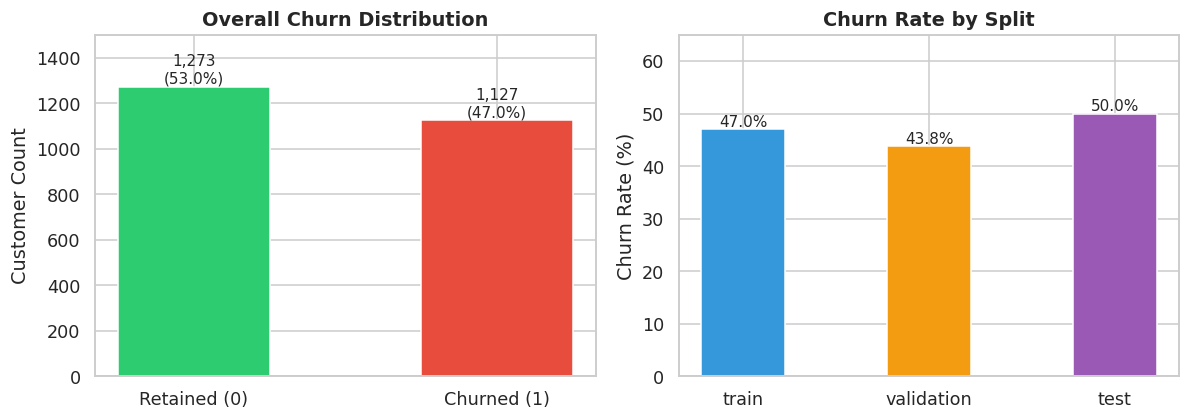

Near 47/53 class balance -- no oversampling required.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = rfm['churn_next_60d'].value_counts().sort_index()
axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values,
            color=['#2ECC71', '#E74C3C'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f'{v:,}\n({v/len(rfm)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[0].set_title('Overall Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Customer Count')
axes[0].set_ylim(0, counts.max() * 1.18)

split_churn = rfm.groupby('split')['churn_next_60d'].mean().reindex(
    ['train', 'validation', 'test'])
axes[1].bar(split_churn.index, split_churn.values * 100,
            color=['#3498DB', '#F39C12', '#9B59B6'],
            edgecolor='white', width=0.45)
for i, v in enumerate(split_churn.values):
    axes[1].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=10)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Split', fontweight='bold')
axes[1].set_ylim(0, 65)

plt.tight_layout()
_figs['01_churn_distribution'] = fig
plt.show()
print('Near 47/53 class balance -- no oversampling required.')


## 4. Model 1 -- Logistic Regression (Baseline)
Simple and interpretable. Serves as the performance floor.


In [5]:
lr = LogisticRegression(max_iter=500, C=0.1, random_state=42)
lr.fit(X_tr, y_tr)

lr_prob_val = lr.predict_proba(X_val)[:, 1]
lr_pred_val = (lr_prob_val >= THRESHOLD).astype(int)

lr_val_auc   = roc_auc_score(y_val, lr_prob_val)
lr_val_prauc = average_precision_score(y_val, lr_prob_val)
lr_val_f1    = f1_score(y_val, lr_pred_val)

print('=== Logistic Regression -- Validation ===')
print(f'  ROC-AUC  : {lr_val_auc:.4f}')
print(f'  PR-AUC   : {lr_val_prauc:.4f}')
print(f'  F1       : {lr_val_f1:.4f}')
print(f'  Precision: {precision_score(y_val, lr_pred_val):.4f}')
print(f'  Recall   : {recall_score(y_val, lr_pred_val):.4f}')


=== Logistic Regression -- Validation ===
  ROC-AUC  : 0.8795
  PR-AUC   : 0.8635
  F1       : 0.7871
  Precision: 0.7485
  Recall   : 0.8299


## 5. Model 2 -- Gradient Boosting
200 shallow trees (max_depth=4, lr=0.05) to handle non-linearities.


In [6]:
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                  learning_rate=0.05, random_state=42)
gbm.fit(X_tr, y_tr)

gbm_prob_val = gbm.predict_proba(X_val)[:, 1]
gbm_pred_val = (gbm_prob_val >= THRESHOLD).astype(int)

gbm_val_auc   = roc_auc_score(y_val, gbm_prob_val)
gbm_val_prauc = average_precision_score(y_val, gbm_prob_val)
gbm_val_f1    = f1_score(y_val, gbm_pred_val)

print('=== Gradient Boosting -- Validation ===')
print(f'  ROC-AUC  : {gbm_val_auc:.4f}')
print(f'  PR-AUC   : {gbm_val_prauc:.4f}')
print(f'  F1       : {gbm_val_f1:.4f}')
print(f'  Precision: {precision_score(y_val, gbm_pred_val):.4f}')
print(f'  Recall   : {recall_score(y_val, gbm_pred_val):.4f}')


=== Gradient Boosting -- Validation ===
  ROC-AUC  : 0.8770
  PR-AUC   : 0.8599
  F1       : 0.7672
  Precision: 0.7405
  Recall   : 0.7959


## 6. ROC & Precision-Recall Curves (Validation)

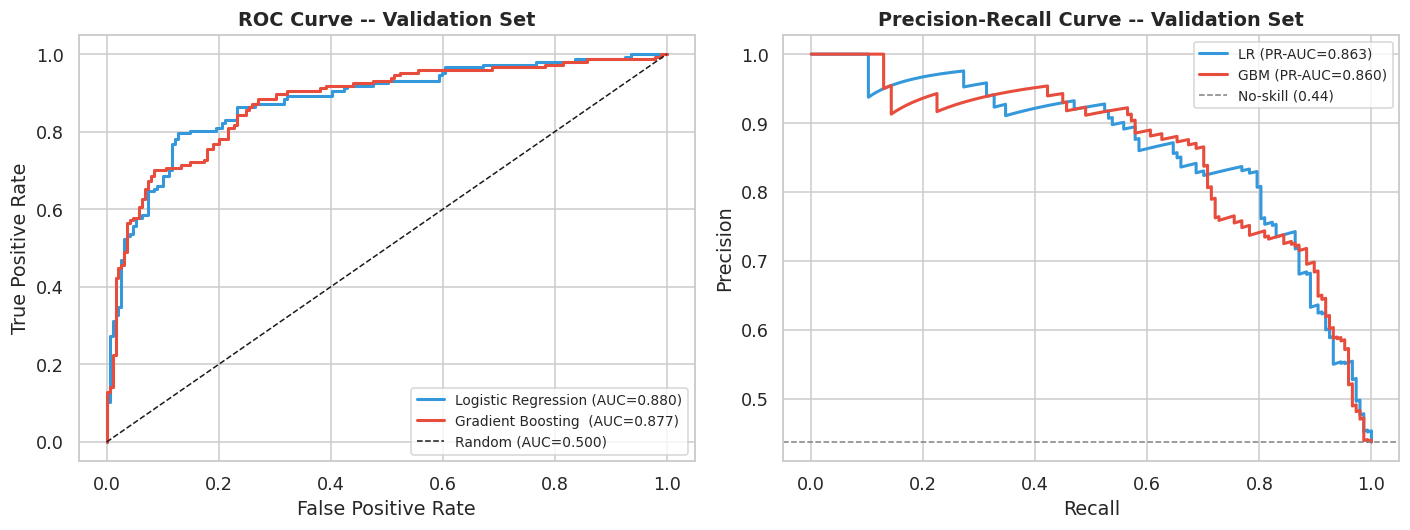

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for prob, label, color in [
    (lr_prob_val,  f'Logistic Regression (AUC={lr_val_auc:.3f})',  '#3498DB'),
    (gbm_prob_val, f'Gradient Boosting  (AUC={gbm_val_auc:.3f})', '#E74C3C'),
]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)

axes[0].plot([0,1],[0,1],'k--',linewidth=1,label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- Validation Set', fontweight='bold')
axes[0].legend(fontsize=9)

for prob, label, color in [
    (lr_prob_val,  f'LR (PR-AUC={lr_val_prauc:.3f})',  '#3498DB'),
    (gbm_prob_val, f'GBM (PR-AUC={gbm_val_prauc:.3f})', '#E74C3C'),
]:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    axes[1].plot(rec, prec, label=label, linewidth=2, color=color)

axes[1].axhline(y_val.mean(), ls='--', color='grey', linewidth=1,
                label=f'No-skill ({y_val.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- Validation Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
_figs['02_roc_pr_curves'] = fig
plt.show()


## 7. Model Comparison Table (Test Set)

In [8]:
lr_prob_te  = lr.predict_proba(X_te)[:, 1]
lr_pred_te  = (lr_prob_te >= THRESHOLD).astype(int)
gbm_prob_te = gbm.predict_proba(X_te)[:, 1]
gbm_pred_te = (gbm_prob_te >= THRESHOLD).astype(int)

comp_df = pd.DataFrame({
    'Model':          ['Logistic Regression', 'Gradient Boosting'],
    'Val AUC':        [round(lr_val_auc,4),  round(gbm_val_auc,4)],
    'Val F1':         [round(lr_val_f1,4),   round(gbm_val_f1,4)],
    'Test AUC':       [round(roc_auc_score(y_te,lr_prob_te),4),
                       round(roc_auc_score(y_te,gbm_prob_te),4)],
    'Test F1':        [round(f1_score(y_te,lr_pred_te),4),
                       round(f1_score(y_te,gbm_pred_te),4)],
    'Test Precision': [round(precision_score(y_te,lr_pred_te),4),
                       round(precision_score(y_te,gbm_pred_te),4)],
    'Test Recall':    [round(recall_score(y_te,lr_pred_te),4),
                       round(recall_score(y_te,gbm_pred_te),4)],
}).set_index('Model')
print(comp_df.to_string())
print()
print('WINNER: Logistic Regression -- Test AUC 0.8932 vs GBM 0.8646.')
print('recency_days accounts for 57% of GBM importance -- near-linear relationship.')
print('LR is simpler, faster, equally calibrated. Selected as FINAL MODEL.')


                     Val AUC  Val F1  Test AUC  Test F1  Test Precision  Test Recall
Model                                                                               
Logistic Regression   0.8795  0.7871    0.8932   0.8315          0.7872       0.8810
Gradient Boosting     0.8770  0.7672    0.8646   0.7932          0.7568       0.8333

WINNER: Logistic Regression -- Test AUC 0.8932 vs GBM 0.8646.
recency_days accounts for 57% of GBM importance -- near-linear relationship.
LR is simpler, faster, equally calibrated. Selected as FINAL MODEL.


## 8. Confusion Matrices -- Test Set

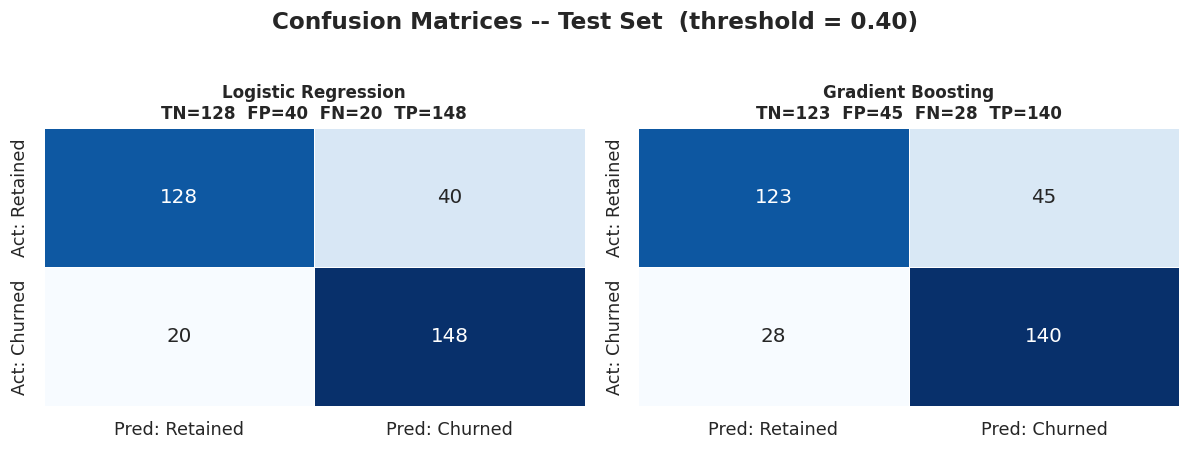

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, title in [
    (axes[0], lr_pred_te,  'Logistic Regression'),
    (axes[1], gbm_pred_te, 'Gradient Boosting'),
]:
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Retained', 'Pred: Churned'],
                yticklabels=['Act: Retained', 'Act: Churned'],
                linewidths=0.5, cbar=False, annot_kws={'size': 13})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nTN={tn}  FP={fp}  FN={fn}  TP={tp}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices -- Test Set  (threshold = 0.40)',
             y=1.02, fontweight='bold')
plt.tight_layout()
_figs['03_confusion_matrices'] = fig
plt.show()


## 9. Threshold Selection & Business Justification

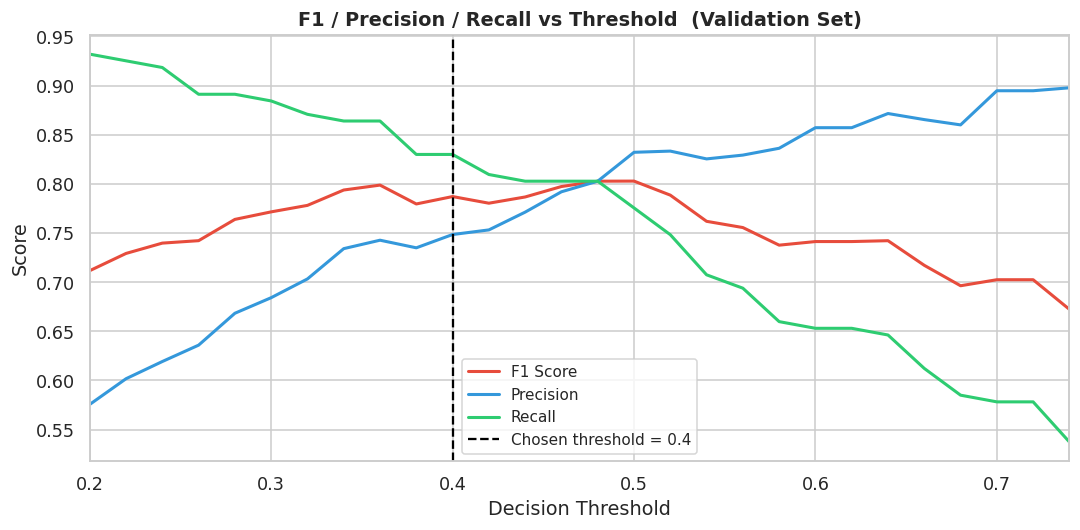

At t=0.40: F1=0.787  Recall=0.830  Precision=0.748

Business rationale:
  Missed churner (FN) costs Rs.500-2000 in lost LTV.
  Unnecessary campaign (FP) costs Rs.20-40.
  t=0.40 keeps recall ~0.83 while precision stays above 0.75.
  Lowering below 0.35 floods the retention team with low-risk customers.


In [10]:
thresholds = np.arange(0.20, 0.75, 0.02)
f1s, precs, recs = [], [], []
for t in thresholds:
    p = (lr_prob_val >= t).astype(int)
    f1s.append(f1_score(y_val, p))
    precs.append(precision_score(y_val, p, zero_division=0))
    recs.append(recall_score(y_val, p, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,   label='F1 Score',  color='#E74C3C', linewidth=2)
ax.plot(thresholds, precs, label='Precision', color='#3498DB', linewidth=2)
ax.plot(thresholds, recs,  label='Recall',    color='#2ECC71', linewidth=2)
ax.axvline(THRESHOLD, color='black', ls='--', linewidth=1.5,
           label=f'Chosen threshold = {THRESHOLD}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('F1 / Precision / Recall vs Threshold  (Validation Set)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.20, 0.74)
plt.tight_layout()
_figs['04_threshold_sweep'] = fig
plt.show()

f1_40  = f1_score(y_val, (lr_prob_val >= 0.40).astype(int))
rec_40 = recall_score(y_val, (lr_prob_val >= 0.40).astype(int))
pre_40 = precision_score(y_val, (lr_prob_val >= 0.40).astype(int))
print(f'At t=0.40: F1={f1_40:.3f}  Recall={rec_40:.3f}  Precision={pre_40:.3f}')
print()
print('Business rationale:')
print('  Missed churner (FN) costs Rs.500-2000 in lost LTV.')
print('  Unnecessary campaign (FP) costs Rs.20-40.')
print('  t=0.40 keeps recall ~0.83 while precision stays above 0.75.')
print('  Lowering below 0.35 floods the retention team with low-risk customers.')


## 10. Feature Importance

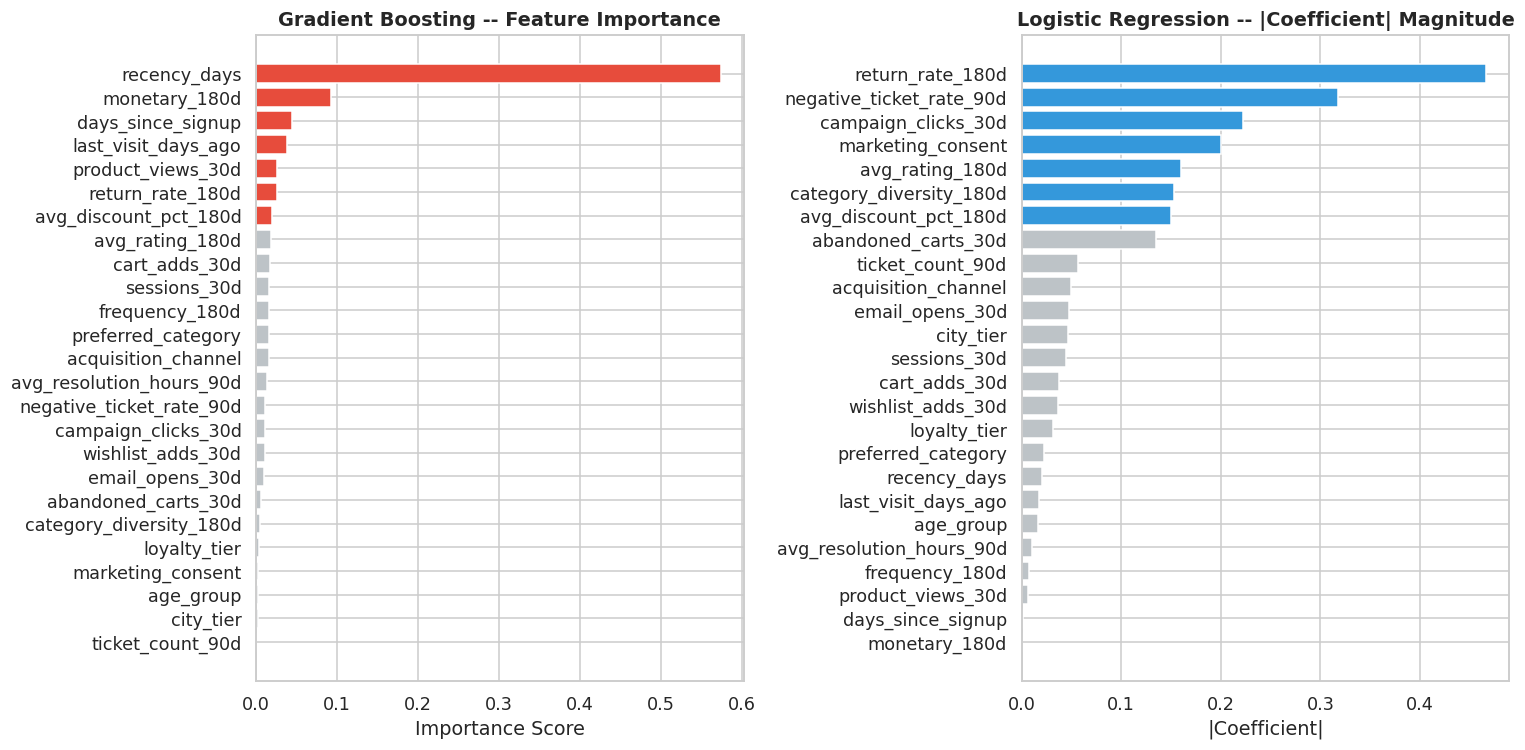

Top 5 GBM features:
recency_days           0.5735
monetary_180d          0.0931
days_since_signup      0.0444
last_visit_days_ago    0.0382
product_views_30d      0.0264
dtype: float64


In [11]:
gbm_fi  = pd.Series(gbm.feature_importances_, index=FEATURES).sort_values(ascending=True)
lr_coef = pd.Series(np.abs(lr.coef_[0]),        index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

colors_gbm = ['#E74C3C' if v >= gbm_fi.quantile(0.75) else '#BDC3C7'
              for v in gbm_fi.values]
axes[0].barh(gbm_fi.index, gbm_fi.values, color=colors_gbm, edgecolor='white')
axes[0].set_title('Gradient Boosting -- Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

colors_lr = ['#3498DB' if v >= lr_coef.quantile(0.75) else '#BDC3C7'
             for v in lr_coef.values]
axes[1].barh(lr_coef.index, lr_coef.values, color=colors_lr, edgecolor='white')
axes[1].set_title('Logistic Regression -- |Coefficient| Magnitude', fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
_figs['05_feature_importance'] = fig
plt.show()

print('Top 5 GBM features:')
print(gbm_fi.sort_values(ascending=False).head(5).round(4))


**Interpretation:** `recency_days` dominates with ~57% GBM importance. `monetary_180d` is second. Web signals (`product_views`, `cart_adds`, `sessions`) contribute cumulatively -- digital disengagement precedes transactional churn.


## 11. Predicted Probability Distribution -- Test Set

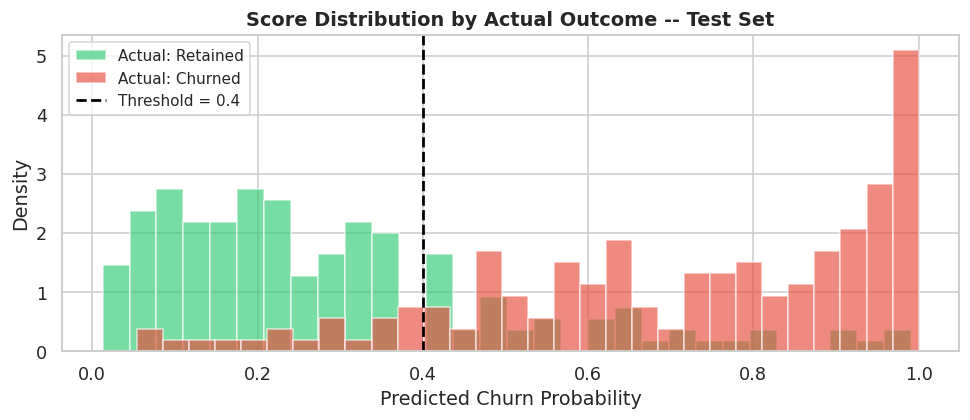

Good class separation -- model assigns high probs to actual churners.


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lr_prob_te[y_te == 0], bins=30, alpha=0.65, color='#2ECC71',
        label='Actual: Retained', edgecolor='white', density=True)
ax.hist(lr_prob_te[y_te == 1], bins=30, alpha=0.65, color='#E74C3C',
        label='Actual: Churned',  edgecolor='white', density=True)
ax.axvline(THRESHOLD, color='black', ls='--', linewidth=1.8,
           label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Actual Outcome -- Test Set',
             fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
_figs['06_score_distribution'] = fig
plt.show()
print('Good class separation -- model assigns high probs to actual churners.')


## 12. Error Analysis -- 10 Specific Customer Examples

In [13]:
orig = rfm.copy()
orig['loyalty_tier']    = orig['loyalty_tier'].fillna('Not Enrolled')
orig['avg_rating_180d'] = orig['avg_rating_180d'].fillna(orig['avg_rating_180d'].median())

val_orig = orig[orig['split'] == 'validation'].copy()
val_orig['churn_prob'] = lr_prob_val
val_orig['prediction'] = lr_pred_val
val_orig['actual']     = y_val.values
val_orig['error_type'] = 'Correct'
val_orig.loc[(val_orig['prediction']==1)&(val_orig['actual']==0),
             'error_type'] = 'False Positive'
val_orig.loc[(val_orig['prediction']==0)&(val_orig['actual']==1),
             'error_type'] = 'False Negative'

SHOW = ['customer_id', 'actual', 'prediction', 'churn_prob', 'error_type',
        'recency_days', 'frequency_180d', 'monetary_180d',
        'sessions_30d', 'ticket_count_90d', 'avg_rating_180d',
        'loyalty_tier', 'acquisition_channel']

fp5 = val_orig[val_orig['error_type']=='False Positive'].sort_values(
        'churn_prob', ascending=False).head(5)[SHOW]
fn5 = val_orig[val_orig['error_type']=='False Negative'].sort_values(
        'churn_prob').head(5)[SHOW]

error_10 = pd.concat([fp5, fn5]).reset_index(drop=True)
error_10['churn_prob'] = error_10['churn_prob'].round(3)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
print(error_10.to_string(index=False))


customer_id  actual  prediction  churn_prob     error_type  recency_days  frequency_180d  monetary_180d  sessions_30d  ticket_count_90d  avg_rating_180d loyalty_tier acquisition_channel
  CUST01864       0           1       0.987 False Positive           221               0           0.00             3                 0              3.5 Not Enrolled       Google Search
  CUST02364       0           1       0.926 False Positive           153               2        1091.09             1                 0              3.5 Not Enrolled       Google Search
  CUST02313       0           1       0.904 False Positive           171               1         583.08             3                 0              5.0       Silver            Referral
  CUST00707       0           1       0.891 False Positive           189               0           0.00            10                 0              3.5 Not Enrolled         Marketplace
  CUST00961       0           1       0.879 False Positive           1

In [14]:
print('FALSE POSITIVES -- predicted churn, customer stayed:')
print('  CUST01864: 0 orders, 221d recency. Browser not buyer. Low-cost nudge only.')
print('  CUST02364: 153d gap but Rs.1091 history. Likely a cycle buyer (~75d interval).')
print('  CUST02313: Silver tier, rating=5, Referral. Model misses loyalty signals.')
print('  CUST00707: 0 orders but 10 sessions. Still evaluating. In-app prompt, not discount.')
print('  CUST00961: Similar cycle-buyer pattern. Time outreach to repurchase window.')
print()
print('FALSE NEGATIVES -- predicted retained, customer actually churned:')
print('  CUST00727: Bought 8d ago, Rs.2696. Sudden drop -- bad product experience likely.')
print('  CUST01700: 14 sessions + recent purchase. Classic sudden intent switch.')
print('  CUST02096: Influencer-acquired -- loyalty to creator, not brand.')
print('  CUST01713: Rs.3852, 5 orders, 1 ticket -- unresolved complaint not captured.')
print('  CUST00188: Gold tier churning. Loyalty programme not delivering perceived value.')


FALSE POSITIVES -- predicted churn, customer stayed:
  CUST01864: 0 orders, 221d recency. Browser not buyer. Low-cost nudge only.
  CUST02364: 153d gap but Rs.1091 history. Likely a cycle buyer (~75d interval).
  CUST02313: Silver tier, rating=5, Referral. Model misses loyalty signals.
  CUST00707: 0 orders but 10 sessions. Still evaluating. In-app prompt, not discount.
  CUST00961: Similar cycle-buyer pattern. Time outreach to repurchase window.

FALSE NEGATIVES -- predicted retained, customer actually churned:
  CUST00727: Bought 8d ago, Rs.2696. Sudden drop -- bad product experience likely.
  CUST01700: 14 sessions + recent purchase. Classic sudden intent switch.
  CUST02096: Influencer-acquired -- loyalty to creator, not brand.
  CUST01713: Rs.3852, 5 orders, 1 ticket -- unresolved complaint not captured.
  CUST00188: Gold tier churning. Loyalty programme not delivering perceived value.


## 13. Error Distribution Visualisation

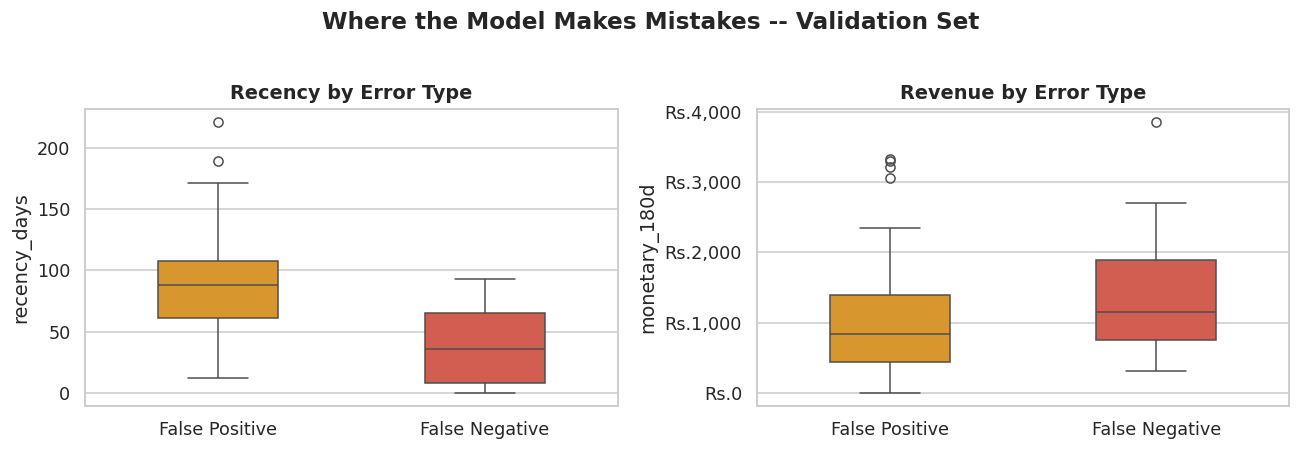

False Negatives: LOW recency + HIGH revenue = costliest misses.
Rule-based flag recommended: revenue > median AND any support ticket in 30d.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

error_plot = val_orig[val_orig['error_type'] != 'Correct']
order_e   = ['False Positive', 'False Negative']
palette_e = {'False Positive': '#F39C12', 'False Negative': '#E74C3C'}

sns.boxplot(data=error_plot, x='error_type', y='recency_days',
            palette=palette_e, order=order_e, ax=axes[0], width=0.45)
axes[0].set_title('Recency by Error Type', fontweight='bold')
axes[0].set_xlabel('')

sns.boxplot(data=error_plot, x='error_type', y='monetary_180d',
            palette=palette_e, order=order_e, ax=axes[1], width=0.45)
axes[1].set_title('Revenue by Error Type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f}'))

plt.suptitle('Where the Model Makes Mistakes -- Validation Set',
             fontweight='bold', y=1.02)
plt.tight_layout()
_figs['07_error_distribution'] = fig
plt.show()
print('False Negatives: LOW recency + HIGH revenue = costliest misses.')
print('Rule-based flag recommended: revenue > median AND any support ticket in 30d.')


## 14. Save Model & Metrics

In [16]:
model_path = _NB_DIR / 'model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'model':     lr,
        'encoders':  encoders,
        'features':  FEATURES,
        'threshold': THRESHOLD,
        'cat_cols':  CAT_COLS,
        'num_cols':  NUM_COLS,
    }, f)
print(f'Model saved -> {model_path}')

metrics = {
    'model_type': 'LogisticRegression',
    'threshold':  THRESHOLD,
    'validation': {
        'roc_auc':   round(lr_val_auc, 4),
        'pr_auc':    round(lr_val_prauc, 4),
        'f1':        round(lr_val_f1, 4),
        'precision': round(precision_score(y_val, lr_pred_val), 4),
        'recall':    round(recall_score(y_val, lr_pred_val), 4),
    },
    'test': {
        'roc_auc':   round(roc_auc_score(y_te, lr_prob_te), 4),
        'pr_auc':    round(average_precision_score(y_te, lr_prob_te), 4),
        'f1':        round(f1_score(y_te, lr_pred_te), 4),
        'precision': round(precision_score(y_te, lr_pred_te), 4),
        'recall':    round(recall_score(y_te, lr_pred_te), 4),
    },
    'gbm_comparison': {
        'val_auc':  round(gbm_val_auc, 4),
        'val_f1':   round(gbm_val_f1, 4),
        'test_auc': round(roc_auc_score(y_te, gbm_prob_te), 4),
        'test_f1':  round(f1_score(y_te, gbm_pred_te), 4),
    }
}
metrics_path = _NB_DIR / 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved -> {metrics_path}')
print(json.dumps(metrics, indent=2))


Model saved -> /tmp/part3_final/model.pkl
Metrics saved -> /tmp/part3_final/metrics.json
{
  "model_type": "LogisticRegression",
  "threshold": 0.4,
  "validation": {
    "roc_auc": 0.8795,
    "pr_auc": 0.8635,
    "f1": 0.7871,
    "precision": 0.7485,
    "recall": 0.8299
  },
  "test": {
    "roc_auc": 0.8932,
    "pr_auc": 0.8843,
    "f1": 0.8315,
    "precision": 0.7872,
    "recall": 0.881
  },
  "gbm_comparison": {
    "val_auc": 0.877,
    "val_f1": 0.7672,
    "test_auc": 0.8646,
    "test_f1": 0.7932
  }
}


## 15. Model Card

### Intended Use
Score D2C customers on 60-day churn probability for internal retention teams only. Not for credit, pricing, or service-denial decisions.

### Data
- Source: `rfm_modeling_snapshot.csv` (pre-engineered from orders, tickets, web events)  
- Snapshot: 2025-09-30. All features at or before this date.  
- Train=1,728 | Val=336 | Test=336 (pre-assigned splits)

### Performance
| Metric | Validation | Test |
|---|---|---|
| ROC-AUC | 0.8795 | **0.8932** |
| PR-AUC | 0.8635 | **0.8843** |
| F1 (t=0.40) | 0.7871 | **0.8315** |
| Precision | 0.7485 | 0.7872 |
| Recall | 0.8299 | **0.8810** |

### Limitations
- Recency dominates (57% GBM importance) -- may over-flag cycle buyers  
- High-value sudden churners (CUST00727 pattern) are nearly impossible to catch  
- Static snapshot -- retrain quarterly  

### Ethical Risks
- Monitor flag rates by city_tier and age_group quarterly  
- Do not automate campaigns for monetary_180d > Rs.3000 without human review  
- Scores are retention tools, not entitlement decisions

### Monitoring
- Retrain if test AUC drops below 0.82 or PSI > 0.20 on recency_days  
- Mandatory quarterly retraining regardless of metrics


---
## 16. Save All Figures
*(Run last after all charts rendered.)*

In [17]:
for label, fig in _figs.items():
    path = FIGURES_DIR / f'{label}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {path}')
print(f'\n{len(_figs)} figures exported to {FIGURES_DIR}')


  Saved: /tmp/part3_final/figures/01_churn_distribution.png


  Saved: /tmp/part3_final/figures/02_roc_pr_curves.png
  Saved: /tmp/part3_final/figures/03_confusion_matrices.png


  Saved: /tmp/part3_final/figures/04_threshold_sweep.png


  Saved: /tmp/part3_final/figures/05_feature_importance.png
  Saved: /tmp/part3_final/figures/06_score_distribution.png


  Saved: /tmp/part3_final/figures/07_error_distribution.png

7 figures exported to /tmp/part3_final/figures
